In [1]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
from src import data, countries, metrics, models, plots

# **1. Configuration and data loading**

**Input data - output results**

In [2]:
# inputs
path_data = r"C:\Users\johanna.cantuna01\Desktop\projects\Bibliometria\data"
study_area = "Mathematics"
fields = [
    "Algebra_and_Number_Theory", "Analysis","Applied_Mathematics", 
    "Computational_Mathematics", "Discrete_Mathematics_and_Combinatorics", "Geometry_and_Topology",
    "Logic","Miscellaneous","Modeling_and_Simulation", "Probability", "Statistics"
]
year_min=2008
year_max=2025

break_year = 2020
# output
outdir = r"C:\Users\johanna.cantuna01\Desktop\projects\Bibliometria\results"
outdir = Path(outdir)
outdir.mkdir(parents=True, exist_ok=True)

**Load data per field and study area**

In [3]:
dfs_by_field_full, df_study_area_full = data.load_all_fields(
    path_data=path_data, 
    fields=fields,
    include_preperiod=True
)

dfs_by_field = {
    field: df_field[df_field["Year"].between(year_min, year_max)].copy()
    for field, df_field in dfs_by_field_full.items()
}

df_study_area = df_study_area_full[df_study_area_full["Year"].between(year_min, year_max)].copy()

# **2. Results for the complete study area**

**1. Cumulative publications and annual publications**

In [4]:
publications_study_area = metrics.publications_per_year(
    df=df_study_area,
    name_column=study_area,
)

publications_study_area_cumulative = publications_study_area.copy()
publications_study_area_cumulative[study_area] = publications_study_area_cumulative[study_area].cumsum()

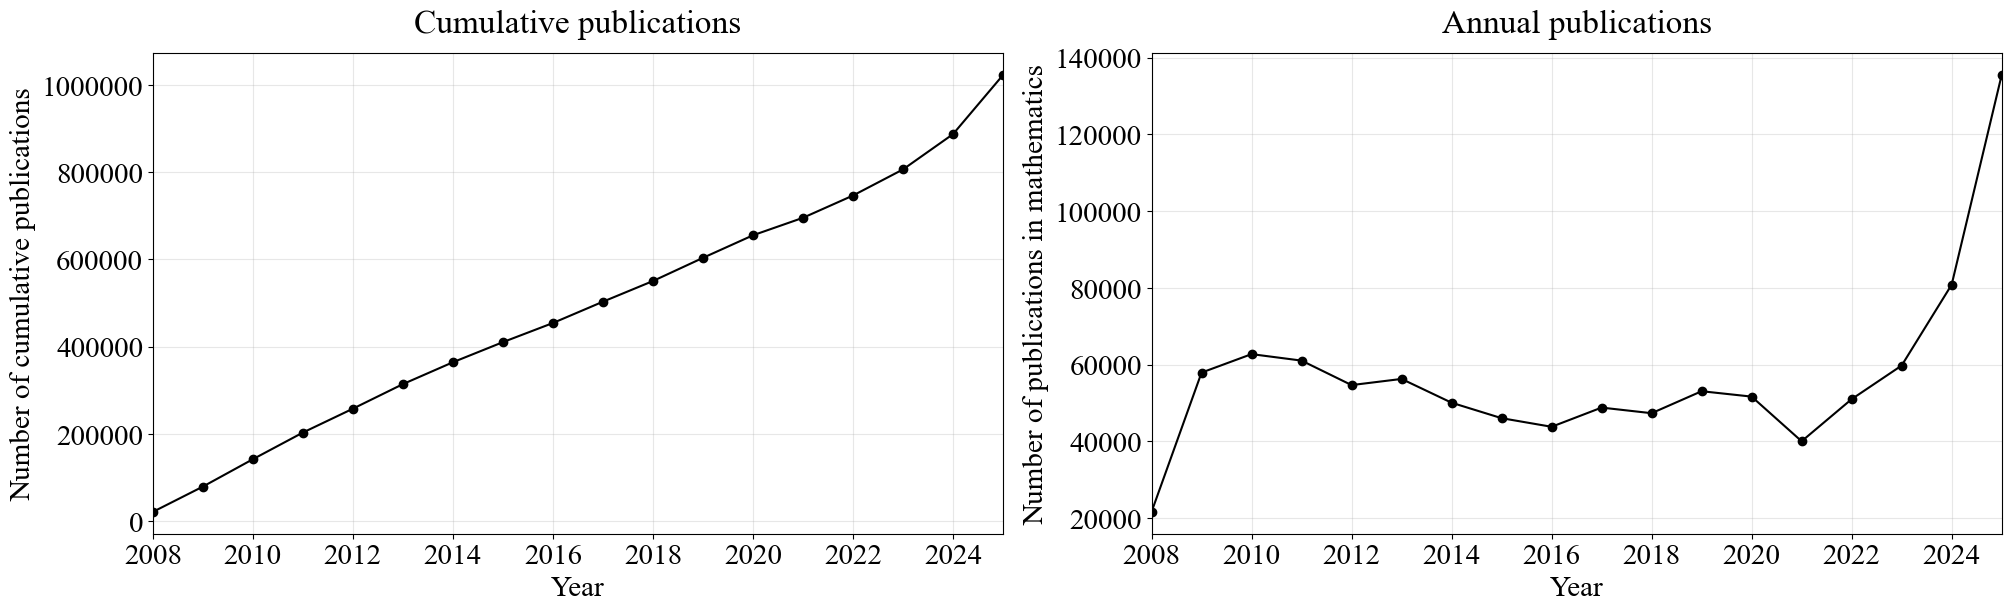

In [5]:
plots.plot_publications_annual_cumulative(
    annual_df=publications_study_area,
    cumulative_df=publications_study_area_cumulative,
    columns=study_area,
    year_min=year_min, 
    year_max=year_max,
    outdir=outdir,
    outname="Math0825ComulatedNormal",
    cumulative_ylabel="Number of cumulative publications",
    annual_ylabel="Number of publications in mathematics",
    add_legend=False,
    cumulative_plain_ticks=True,
)

**2. Global fit and piecewise fit**

In [6]:
# compute best fit results for all data
bestFit_study_area, resultsFit_study_area = models.fit_best_growth_model(
    df=publications_study_area,
    name_column=study_area,
)

# compute best fit results per interval
df_pre  = publications_study_area[publications_study_area["Year"] <= break_year]
df_post = publications_study_area[publications_study_area["Year"] > break_year]

bestFit_study_area_pre, resultsFit_study_area_pre = models.fit_best_growth_model(
    df=df_pre,
    name_column=study_area,
    models=["poly3"]
)
bestFit_study_area_post, resultsFit_study_area_post = models.fit_best_growth_model(
    df=df_post,
    name_column=study_area,
    models=["exponential"]
)

In [7]:
print("\n" + "=" * 60)
print(f"{study_area} — Global fit")
print(f"Model: {bestFit_study_area['model']} | R² = {bestFit_study_area['r2']:.3f} | AIC = {bestFit_study_area['aic']:.2f}")
print(models.format_equation(
    best=bestFit_study_area,
    year0=publications_study_area["Year"].min(),
    decimals=2,
))
print("\n" + "=" * 60)
print(f"{study_area} — PRE interval")
print(f"Years: {df_pre['Year'].min()}–{df_pre['Year'].max()}")
print(f"Model: {bestFit_study_area_pre['model']} | R² = {bestFit_study_area_pre['r2']:.3f} | AIC = {bestFit_study_area_pre['aic']:.2f}")
print(models.format_equation(
        best=bestFit_study_area_pre,
        year0=df_pre["Year"].min(),
        decimals=2,
))
print("\n" + "=" * 60)
print(f"{study_area} — POST interval")
print(f"Years: {df_post['Year'].min()}–{df_post['Year'].max()}")
print(f"Model: {bestFit_study_area_post['model']} | R² = {bestFit_study_area_post['r2']:.3f} | AIC = {bestFit_study_area_post['aic']:.2f}")
print(models.format_equation(
        best=bestFit_study_area_post,
        year0=df_post["Year"].min(),
        decimals=2
))


Mathematics — Global fit
Model: poly3 | R² = 0.841 | AIC = 335.24
--------> {'degree': 3, 'coefficients': [131.87951496387993, -2944.63170794633, 17163.481811145502, 31421.350877192966]}
y = 131.88(Year - 2008)^3 - 2944.63(Year - 2008)^2 + 17163.48(Year - 2008) + 31421.35

Mathematics — PRE interval
Years: 2008–2020
Model: poly3 | R² = 0.657 | AIC = 233.40
--------> {'degree': 3, 'coefficients': [185.7645687645688, -3599.235264735258, 18625.327838827758, 31687.747252747435]}
y = 185.76(Year - 2008)^3 - 3599.24(Year - 2008)^2 + 18625.33(Year - 2008) + 31687.75

Mathematics — POST interval
Years: 2021–2025
Model: exponential | R² = 0.932 | AIC = 94.85
--------> {'a': 10.531283771917625, 'b': 0.2897135016831401, 'doubling_time': 2.39252632871091}
log(y) = 10.53 + 0.29 (Year - 2021)
y = 37469.55 · exp(0.29 (Year - 2021))   |   T = 2.39 years


In [8]:
np.exp(10.531283771917625)

37469.54587121905

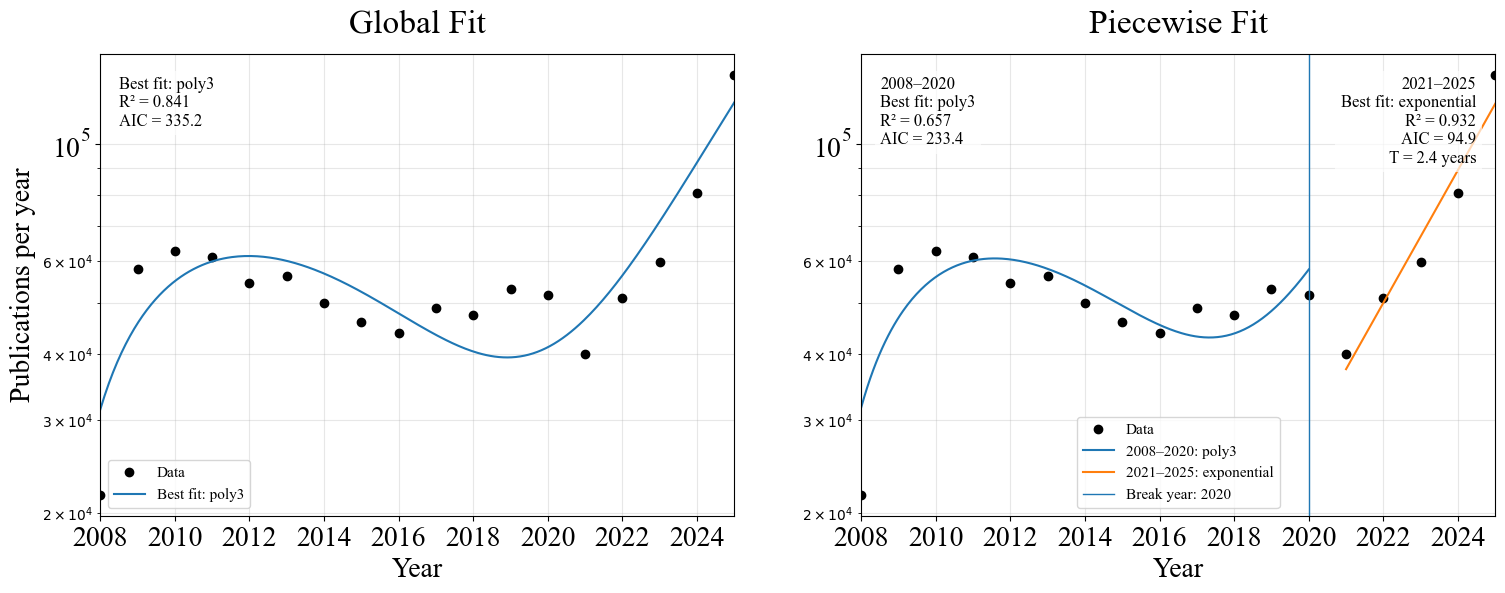

In [9]:
plots.plot_global_segmented_fits(
    df=publications_study_area,
    name_column=study_area,
    best_global=bestFit_study_area,
    best_pre=bestFit_study_area_pre,
    best_post=bestFit_study_area_post,
    break_year=break_year,
    year_min=year_min,
    year_max=year_max,
    outdir=outdir,
    outname="fitMathCombined",
    use_semilogy=True,
    text_loc_global="tl",
    text_loc_pre="tl",
    text_loc_post="tr",
)

**3. Document type distribution**

In [10]:
document_type_counts = (
    df_study_area["Document Type"]
    .value_counts()
    .to_frame(name=study_area)
)

document_type_shares = metrics.document_type_share_by_year(
    df=df_study_area,
    doc_types=("Conference paper", "Article"),
)

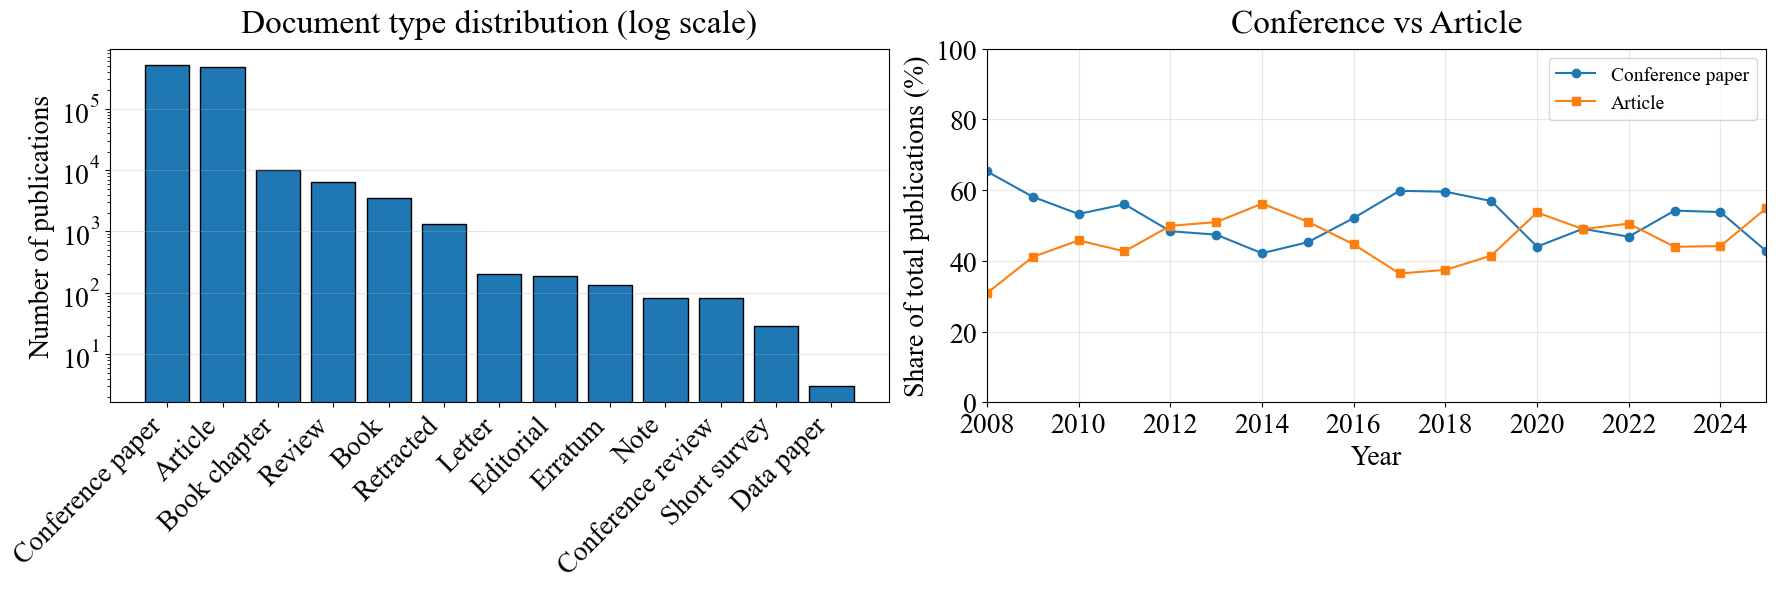

In [11]:
plots.plot_document_type_analysis(
    document_type_counts=document_type_counts,
    document_type_shares=document_type_shares,
    count_column=study_area,
    share_columns=["Conference paper_percent", "Article_percent",],
    share_labels=["Conference paper", "Article",],
    year_min=year_min,
    year_max=year_max,
    outdir=outdir,
    outname="DocTypeCombinedMath",
    title_share="Conference vs Article",
)

**4. Commuties of authors**

In [12]:
community_study_area = metrics.compute_author_communities(
    df=df_study_area,
    window=5,
)

df_study_area_full = data.build_full_for_community(
    df_main = df_study_area, 
    df_hist = df_study_area_full
)
    
community_study_area_full = metrics.compute_author_communities(
    df = df_study_area_full, 
    window=5
)

community_2008_2025 = community_study_area_full[(community_study_area_full["Year"] >= year_min) & (community_study_area_full["Year"] <= year_max)].copy()

best_community_truncated, results_community_truncated = models.fit_best_growth_model(
    df=community_study_area,
    name_column="Community_c",
    models=["linear", "exponential", "poly2", "poly3", "logistic"],
    criterion="aic",
)

best_community_full, results_community_full = models.fit_best_growth_model(
    df=community_2008_2025,
    name_column="Community_c",
    models=["linear", "exponential", "poly2", "poly3", "logistic"],
    criterion="aic",
)

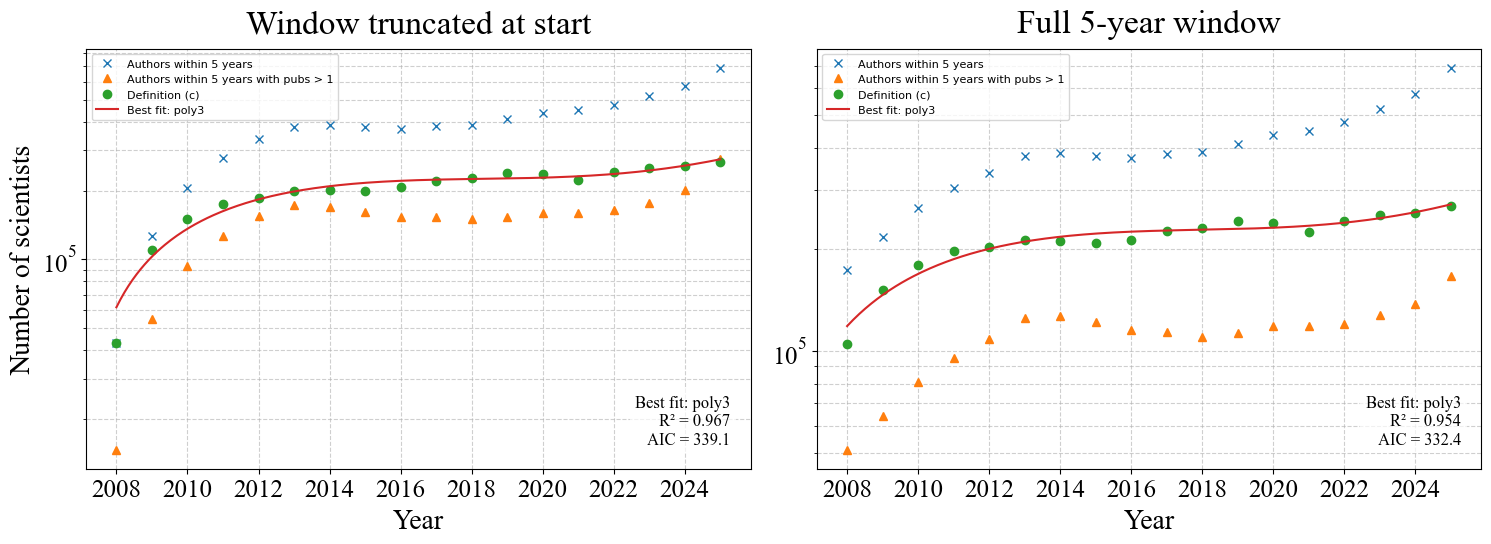

In [13]:
plots.plot_author_communities_truncation_comparison(
    community_truncated=community_study_area,
    community_full=community_2008_2025,
    best_truncated=best_community_truncated,
    best_full=best_community_full,
    year_min=year_min,
    year_max=year_max,
    outdir=outdir,
    outname="MathComunityAutohrsComb",
    add_legend=True,
    text_loc_truncated="br",
    text_loc_full="br",
)

**5. Productivity by author**

In [14]:
prod_study_area, freq_study_area, mean_prod_study_area = metrics.compute_author_productivity(
    df=df_study_area
)
best_study_area = models.find_best_two_powerlaws(
    freq=freq_study_area, 
    min_points=6
)

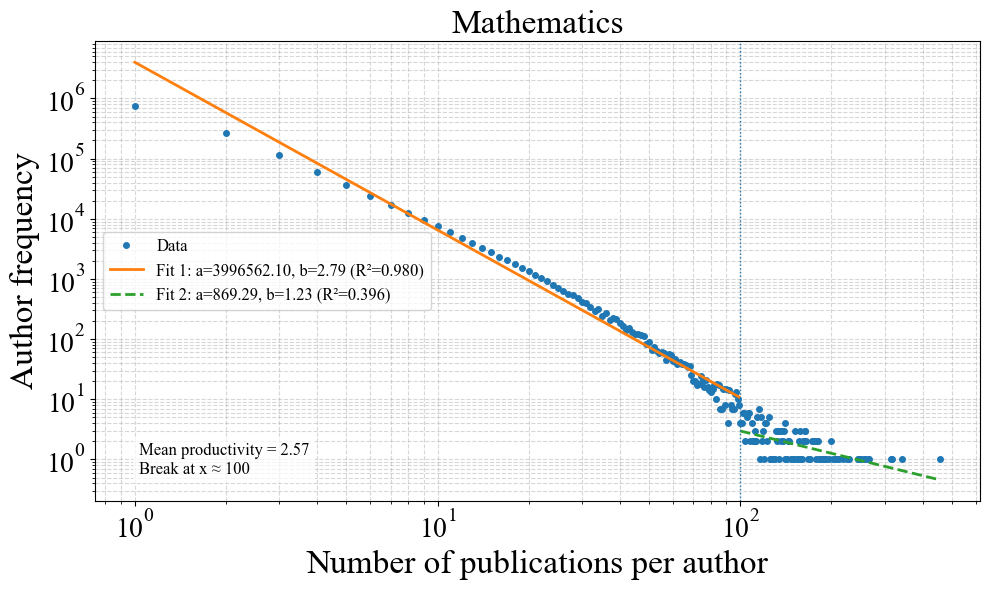


=== Two power-law fits (auto) ===
Break x ≈ 100.0
Fit 1: y = 3996562.10 / x^2.79 R2 = 0.9799
Fit 2: y = 869.29 / x^1.23 R2 = 0.3962


In [15]:
res = plots.plot_author_productivity_twofits_auto(
    mean_prod=mean_prod_study_area,
    best=best_study_area,
    name=study_area,
    outdir=outdir,
    outname="ProdauthorMath"
)

In [16]:
print(res)

{'mean_prod': 2.5654646933540475, 'break_x': 100.0, 'fit1': {'a': 3996562.0961514753, 'b': 2.788431791576026, 'r2': 0.9798512961116395, 'sse': 13.48163043903254}, 'fit2': {'a': 869.2875203048762, 'b': 1.23308778402635, 'r2': 0.3962482372616909, 'sse': 21.502423875617108}}


**6. Bradford's Law**

In [17]:
df_study_area_count = metrics.clean_journal_counts(
    df = df_study_area
)
stats_study_area = metrics.bradford_stats(
    journal_counts=df_study_area_count, 
    top_frac=0.10, 
)

leimkuhler_compute_study_area = metrics.leimkuhler(
    x = np.linspace(1, len(stats_study_area["ranks"]), 800),
    a = stats_study_area["a"],
    b = stats_study_area["b"],
)

print(f"\n=== Bradford / Leimkuhler ({study_area}) ===")
print(f"a = {stats_study_area["a"]:.2f}")
print(f"b = {stats_study_area["b"]:.2f}")
print(f"Ecuation: C(r) = {stats_study_area["a"]:.2f} · ln(1 + {stats_study_area["b"]:.2f} · r)")
print(f"Top 10%: top_n={stats_study_area["top_n"]} journals → {stats_study_area["percent_top"]}% of publications")


=== Bradford / Leimkuhler (Mathematics) ===
a = 126433.10
b = 0.95
Ecuation: C(r) = 126433.10 · ln(1 + 0.95 · r)
Top 10%: top_n=79 journals → 65.887124472566% of publications


c:\Users\johanna.cantuna01\Desktop\projects\Bibliometria\src\metrics.py:105: RuntimeWarning: invalid value encountered in log
  return a * np.log(1 + b*x)


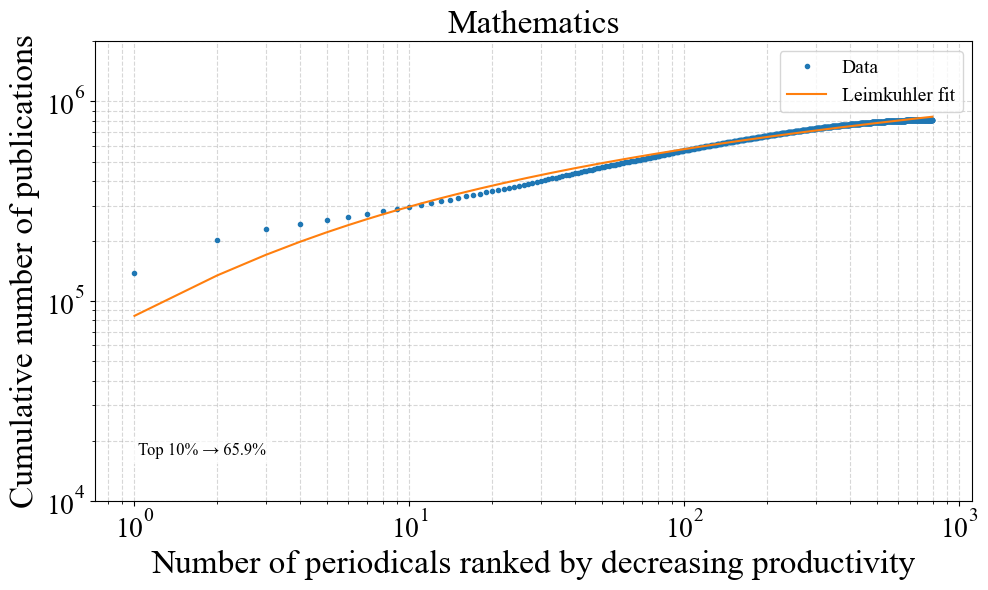

(10000.0, 2000000.0)


In [18]:
plots.plot_bradford_single(
    ranks=stats_study_area["ranks"],
    cumulative=stats_study_area["cumulative"],
    percent_top=stats_study_area['percent_top'],
    leimkuhler_compute=leimkuhler_compute_study_area,
    x_dense=np.linspace(1, len(stats_study_area["ranks"]), 800),
    outdir=outdir,
    outname="Bradfordmath",
    top_frac=0.10,
)

**7. Study area production by country**

In [19]:
with open("country_patterns.json", "r", encoding="utf-8") as f:
    COUNTRY_PATTERNS = json.load(f)

df_study_area_article =  df_study_area[df_study_area["Document Type"] == "Article"]
df_study_area_cp =  df_study_area[df_study_area["Document Type"] == "Conference paper"]

tagged_study_area_article = countries.tag_countries_from_affiliations(
    df=df_study_area_article,
    col_affil="Affiliations",
    country_patterns=COUNTRY_PATTERNS,
    out_col_list="countries_list",
    out_col_str="countries_str"
)
country_counts_study_area_article = (tagged_study_area_article.explode("countries_list").dropna(subset=["countries_list"])["countries_list"].value_counts())

tagged_study_area_cp = countries.tag_countries_from_affiliations(
    df=df_study_area_cp,
    col_affil="Affiliations",
    country_patterns=COUNTRY_PATTERNS,
    out_col_list="countries_list",
    out_col_str="countries_str"
)
country_counts_study_area_cp = (tagged_study_area_cp.explode("countries_list").dropna(subset=["countries_list"])["countries_list"].value_counts())

In [20]:
total_study_area_articles = len(tagged_study_area_article)
print("=========== Study area articles ===========")
top10_sa_articles = (
    country_counts_study_area_article
    .head(10)
    .to_frame("publications")
    .assign(percent=lambda x: x["publications"] / total_study_area_articles * 100).round(2)
)
print(top10_sa_articles)

total_study_area_cp = len(tagged_study_area_cp)
print("=========== Study area conference paper ===========")
top10_sa_cp = (
    country_counts_study_area_cp
    .head(10)
    .to_frame("publications")
    .assign(percent=lambda x: x["publications"] / total_study_area_cp * 100).round(2)
)
print(top10_sa_cp)


=========== Study area articles ===========
                publications  percent
countries_list                       
China                 165939    34.60
United States          80621    16.81
India                  29913     6.24
United Kingdom         29316     6.11
France                 25148     5.24
Germany                24954     5.20
Italy                  19691     4.11
Canada                 16580     3.46
Spain                  15551     3.24
Iran                   14964     3.12
=========== Study area conference paper ===========
                publications  percent
countries_list                       
China                 139780    26.82
United States          92120    17.68
India                  40382     7.75
Germany                33352     6.40
United Kingdom         27799     5.33
France                 27205     5.22
Japan                  20465     3.93
Italy                  18811     3.61
Canada                 15156     2.91
Spain                  12738  

# **3. Results by subfield**

**1. Cumulative publications and annual publications**

In [21]:
publications_by_field = {}

for field, df_field in dfs_by_field.items():
    field_per_year = metrics.publications_per_year(
        df=df_field,
        name_column=field,
    )
    publications_by_field[field] = field_per_year

publications_per_year_fields = (
    pd.concat([df_field.set_index("Year") for df_field in publications_by_field.values()], axis = 1,)
    .fillna(0)
    .sort_index()
    .reset_index()
)

publications_cumulative_fields = publications_per_year_fields.copy()
publications_cumulative_fields[fields] = (publications_cumulative_fields[fields].cumsum())

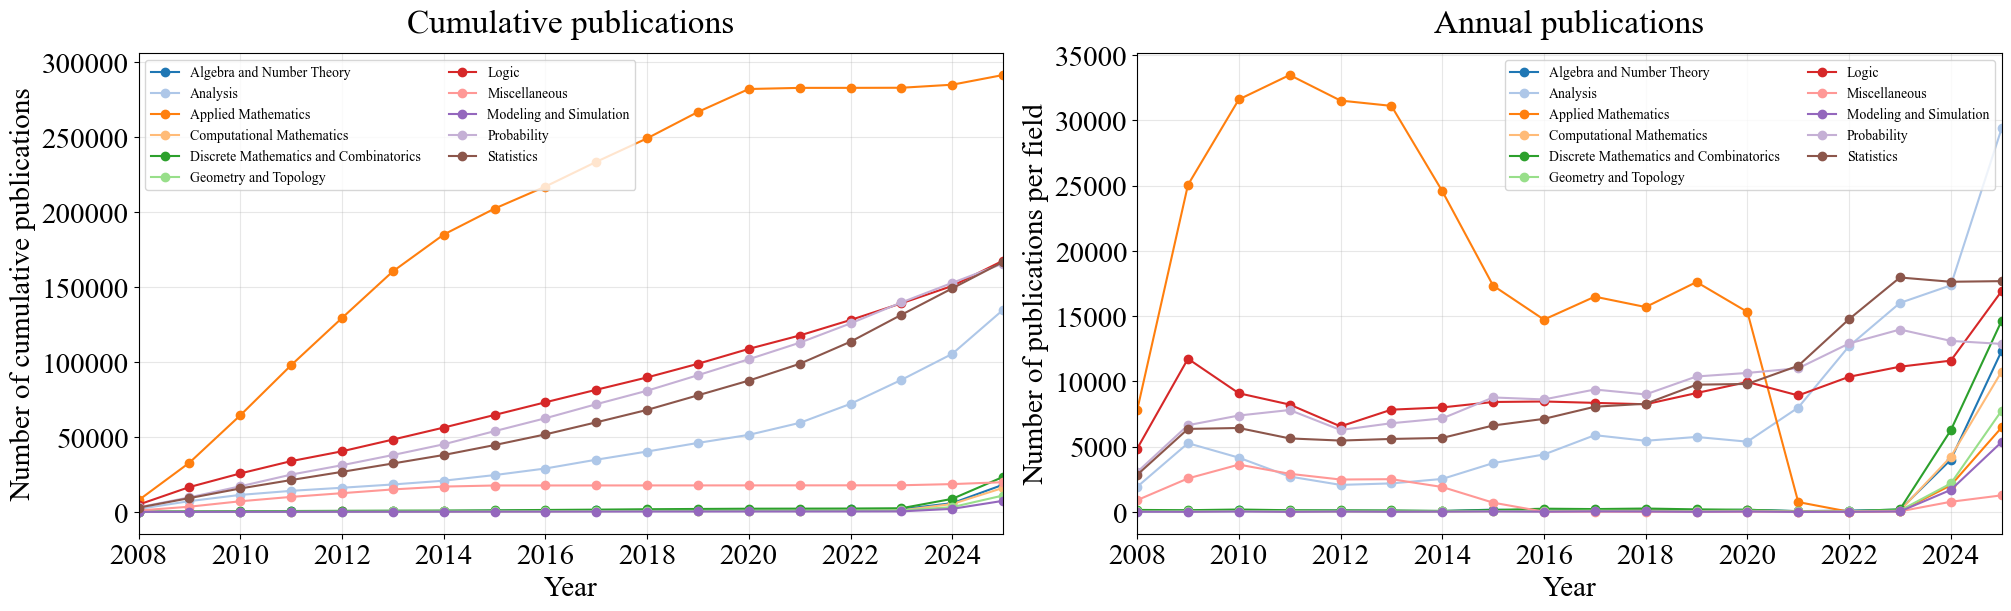

In [22]:
plots.plot_publications_annual_cumulative(
    annual_df=publications_per_year_fields,
    cumulative_df=publications_cumulative_fields,
    columns=fields,
    year_min=year_min,
    year_max=year_max,
    outdir=outdir,
    outname="Fields0825CumAnnualCombined",
    cumulative_ylabel="Number of cumulative publications",
    annual_ylabel="Number of publications per field",
    add_legend=True,
)

**2. Piecewise Fit**

In [23]:
field_groups = {
    "01": ["Algebra_and_Number_Theory", "Analysis", "Applied_Mathematics"],
    "02": ["Computational_Mathematics", "Discrete_Mathematics_and_Combinatorics", "Geometry_and_Topology"],
    "03": ["Logic", "Miscellaneous", "Modeling_and_Simulation"],
    "04": ["Probability", "Statistics"],
}

forced_models_growth = {
    "Algebra_and_Number_Theory":{"pre": ["poly3"], "post": ["exponential"]},
    "Analysis":{"pre": ["poly3"], "post": ["poly3"]},
    "Applied_Mathematics":{"pre": ["poly3"], "post": ["logistic"]},
    "Computational_Mathematics":{"pre": ["poly3"], "post": ["exponential"]},
    "Discrete_Mathematics_and_Combinatorics":{"pre": ["poly3"], "post": ["exponential"]},
    "Geometry_and_Topology":{"pre": ["poly3"], "post": ["exponential"]},
    "Logic":{"pre": ["poly3"], "post": ["poly3"]},
    "Miscellaneous":{"segments": [["poly3"], ["poly3"], ["exponential"]]},
    "Modeling_and_Simulation":{"pre": ["poly3"], "post": ["exponential"]},
    "Probability":{"pre": ["linear"], "post": ["poly3"]},
    "Statistics":{"pre": ["exponential"], "post": ["poly2"]},
}

In [24]:
growth_fits_by_field = {}

for field, publications_field in publications_by_field.items():
    if field == "Miscellaneous":
        field_special = field
        periods_special = [(2008, 2016), (2017, 2020), (2021, 2025)]
        labels_special = ["S1 (2008–2016)", "S2 (2017–2020)", "S3 (2021–2025)"]
    else:
        field_special, periods_special, labels_special = None, None, None

    field_segments = metrics.get_growth_segments(
        df=publications_field,
        field=field,
        break_year=break_year,
        forced_models_growth=forced_models_growth,
        field_special= field_special,
        periods_special=periods_special,
        labels_special=labels_special
    )

    segment_results = []

    for segment in field_segments:
        df_segment = publications_field[publications_field["Year"].between(segment["year_min"], segment["year_max"])].copy()

        if len(df_segment) < 3:
            print(f"[WARNING] {field} — {segment['label']}: only {len(df_segment)} observations; segment omitted.")
            continue

        best_fit, all_results = models.fit_best_growth_model(
            df=df_segment,
            name_column=field,
            models=segment["models"],
            criterion="aic",
        )

        segment_results.append({**segment, "df": df_segment, "best_fit": best_fit, "all_results": all_results,}) 

    growth_fits_by_field[field] = segment_results

for field in fields:
    print("\n" + "=" * 50)
    print(field.replace("_", " "))

    for segment_result in growth_fits_by_field[field]:
        best_fit = segment_result["best_fit"] 
        df_segment = segment_result["df"]
        segment_label = segment_result["label"]
        initial_year = int(df_segment["Year"].min())
        print(
            f"{segment_label} | "
            f"model={best_fit['model']} | "
            f"R²={best_fit['r2']:.3f} | "
            f"AIC={best_fit['aic']:.2f}"
        )

        print(models.format_equation(best = best_fit, year0=initial_year))


Algebra and Number Theory
PRE (≤2020) | model=poly3 | R²=0.454 | AIC=97.48
--------> {'degree': 3, 'coefficients': [-0.07692307692307497, 1.5809190809190432, -1.2072927072925164, 77.81318681318653]}
y = -0.08(Year - 2008)^3 + 1.58(Year - 2008)^2 - 1.21(Year - 2008) + 77.81
POST (>2020) | model=exponential | R²=0.911 | AIC=76.54
--------> {'a': 3.4388671291957515, 'b': 1.4352442760775082, 'doubling_time': 0.48294718335634246}
log(y) = 3.44 + 1.44 (Year - 2021)
y = 31.15 · exp(1.44 (Year - 2021))   |   T = 0.48 years

Analysis
PRE (≤2020) | model=poly3 | R²=0.525 | AIC=187.73
--------> {'degree': 3, 'coefficients': [-5.112762237762101, 132.4557942057915, -667.3567682317541, 3729.815934065916]}
y = -5.11(Year - 2008)^3 + 132.46(Year - 2008)^2 - 667.36(Year - 2008) + 3729.82
POST (>2020) | model=poly3 | R²=0.990 | AIC=73.59
--------> {'degree': 3, 'coefficients': [1007.2499999999967, -5137.357142857127, 9782.178571428547, 7806.38571428574]}
y = 1007.25(Year - 2021)^3 - 5137.36(Year - 2021

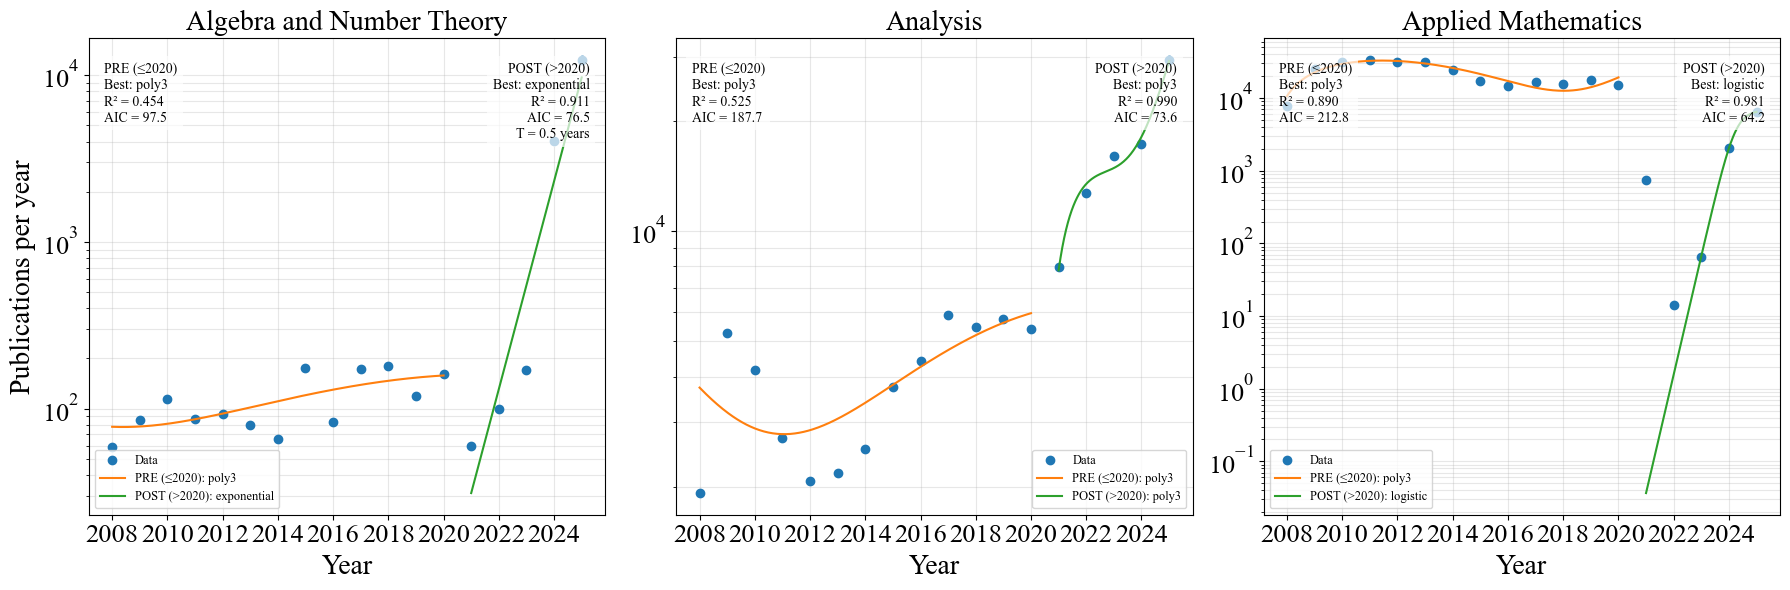

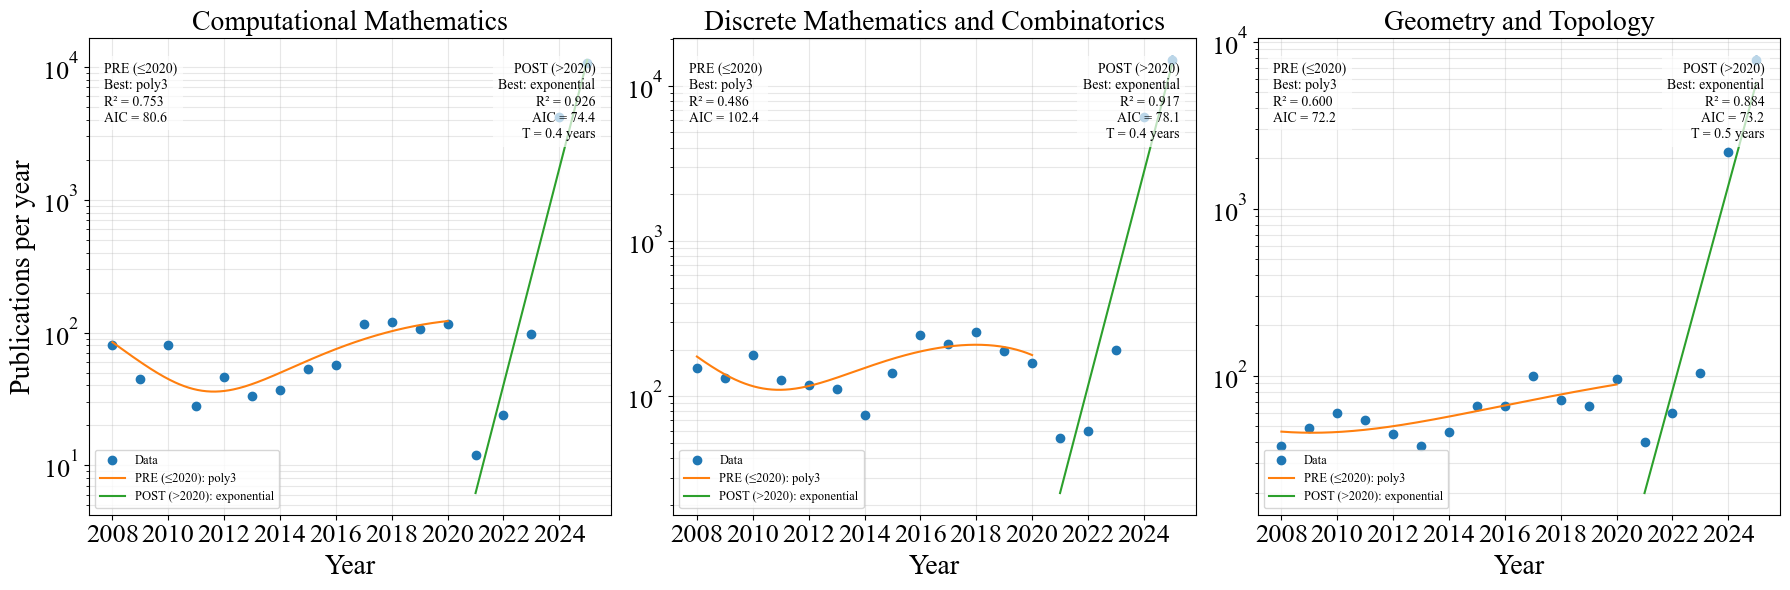

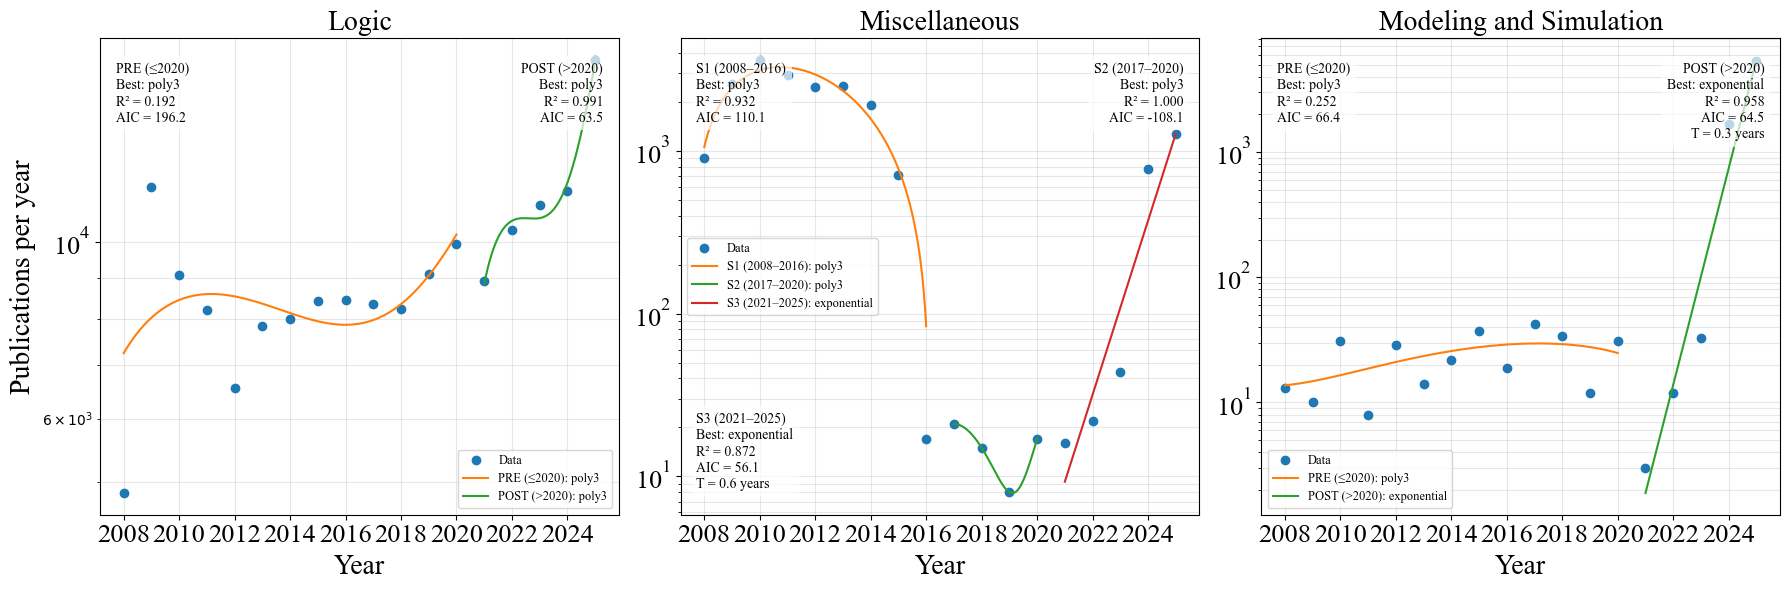

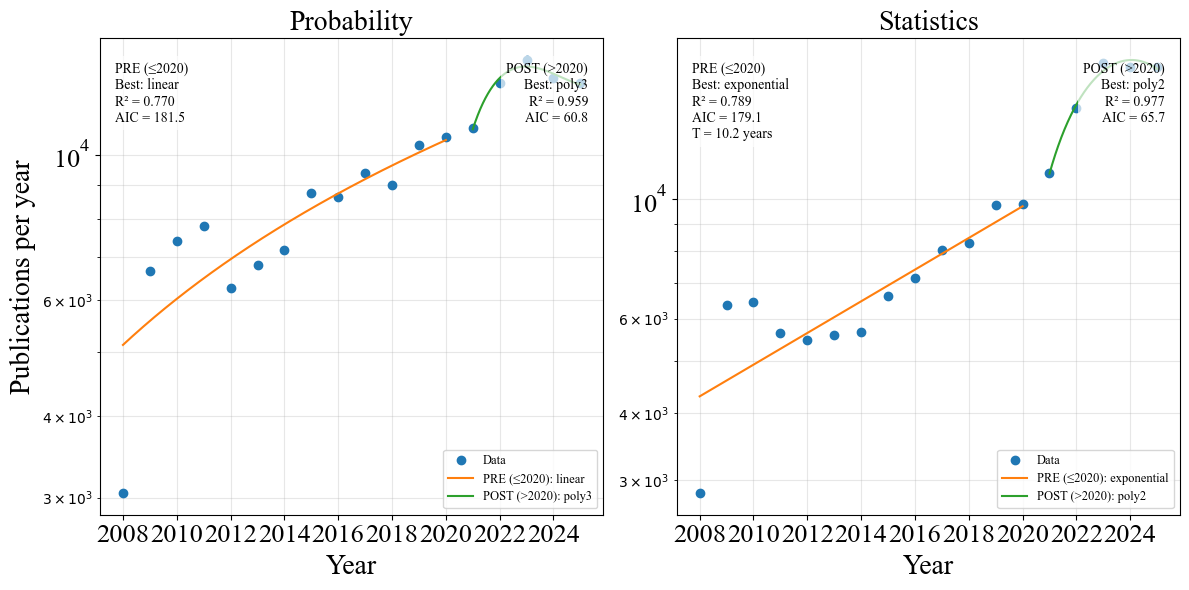

In [25]:
for group_id, fields_group in field_groups.items():
    plots.plot_field_segmented_growth_group(
        fields_group=fields_group,
        publications_by_field=publications_by_field,
        growth_fits_by_field=growth_fits_by_field,
        outdir=outdir,
        outname=f"fitFieldSplit0825_{group_id}",
        figsize_unit=(6, 6),
        fontsize=20,
        use_semilogy=True,
    )

**3. Community growth by subareas**

In [26]:
forced_community_growth = {
    "Algebra_and_Number_Theory": [("linear", 2008, 2020), ("exponential", 2021, 2025)],
    "Computational_Mathematics": [("poly2", 2008, 2020), ("exponential", 2021, 2025)],
    "Discrete_Mathematics_and_Combinatorics": [("poly2", 2008, 2020), ("exponential", 2021, 2025)],
    "Geometry_and_Topology": [("poly2", 2008, 2020), ("exponential", 2021, 2025)],
    "Logic": [("poly2", 2008, 2020), ("exponential", 2021, 2025)],
    "Modeling_and_Simulation": [("poly2", 2008, 2020), ("exponential", 2021, 2025)],
    "Miscellaneous": [("linear", 2008, 2019), ("exponential", 2020, 2025)]
}

In [27]:
community_by_field = {}

for field, df_field_full in dfs_by_field_full.items():

    community_full = metrics.compute_author_communities(
        df=df_field_full,
        window=5,
    )
    community_by_field[field] = (community_full[community_full["Year"].between(year_min, year_max)].sort_values("Year").reset_index(drop=True).copy())

community_growth_fits_by_field = {}
candidate_models = ["linear", "exponential", "poly2", "poly3", "logistic",]

for field in fields:

    community_df = community_by_field[field]
    if field in forced_community_growth:
        fit_result = models.fit_forced_growth_segments(
            df=community_df,
            name_column="Community_c",
            segments=forced_community_growth[field],
            criterion="aic",
        )
    else:
        best_fit, all_results = models.fit_best_growth_model(
            df=community_df,
            name_column="Community_c",
            models=candidate_models,
            criterion="aic",
        )
        fit_result = {"fit_type": "global", "model": best_fit["model"], "best_fit": best_fit, "all_results": all_results,}
    community_growth_fits_by_field[field] = fit_result

for field in fields:
    fit_result = community_growth_fits_by_field[field]
    print("\n" + "=" * 50)
    print(field)
    if fit_result["fit_type"] == "segments":
        valid_parts = [part for part in fit_result["parts"] if part.get("status") == "ok"]
        for part_index, part in enumerate(valid_parts):
            start_year, end_year = part["years_range"]
            if part_index == 0:
                segment_name = f"PRE (≤{end_year})"
            elif part_index == 1:
                segment_name = f"POST (>{start_year - 1})"
            else:
                segment_name = (f"SEGMENT ({start_year}–{end_year})")
            print(f"\n{segment_name} model: {part['model']} | R²={part['r2']:.3f} | AIC={part['aic']:.2f}")
            print(models.format_equation(best=part, year0=start_year, decimals=2))

    else:

        best_fit = fit_result["best_fit"]
        print(f"Best model: {best_fit['model']} | R²={best_fit['r2']:.3f} | AIC={best_fit['aic']:.2f}")
        print(models.format_equation(best=best_fit, year0=int(community_by_field[field]["Year"].min()), decimals=2))


Algebra_and_Number_Theory

PRE (≤2020) model: linear | R²=0.925 | AIC=107.67
--------> {'intercept': 163.76923076923072, 'slope': 50.57692307692309}
y = 163.77 + 50.58 (Year - 2008)

POST (>2020) model: exponential | R²=0.882 | AIC=88.15
--------> {'a': 5.722107209817166, 'b': 1.1074644214356129, 'doubling_time': 0.6258866354021688}
log(y) = 5.72 + 1.11 (Year - 2021)
y = 305.55 · exp(1.11 (Year - 2021))   |   T = 0.63 years

Analysis
Best model: poly3 | R²=0.977 | AIC=300.27
--------> {'degree': 3, 'coefficients': [25.006578947368315, -271.8553921568604, 1792.6950464396145, 15113.140350877207]}
y = 25.01(Year - 2008)^3 - 271.86(Year - 2008)^2 + 1792.7(Year - 2008) + 15113.14

Applied_Mathematics
Best model: poly3 | R²=0.938 | AIC=338.43
--------> {'degree': 3, 'coefficients': [145.63567824790684, -4370.993722050216, 29863.564442151117, 56889.935672514584]}
y = 145.64(Year - 2008)^3 - 4370.99(Year - 2008)^2 + 29863.56(Year - 2008) + 56889.94

Computational_Mathematics

PRE (≤2020) mode

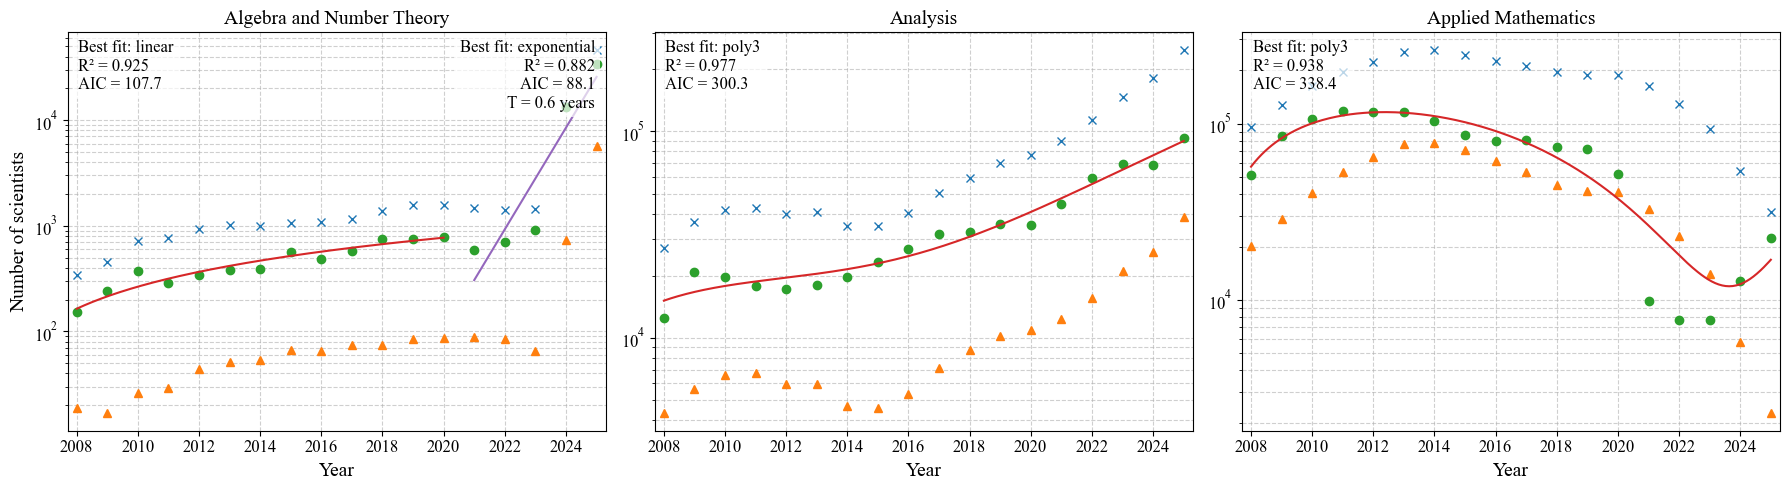

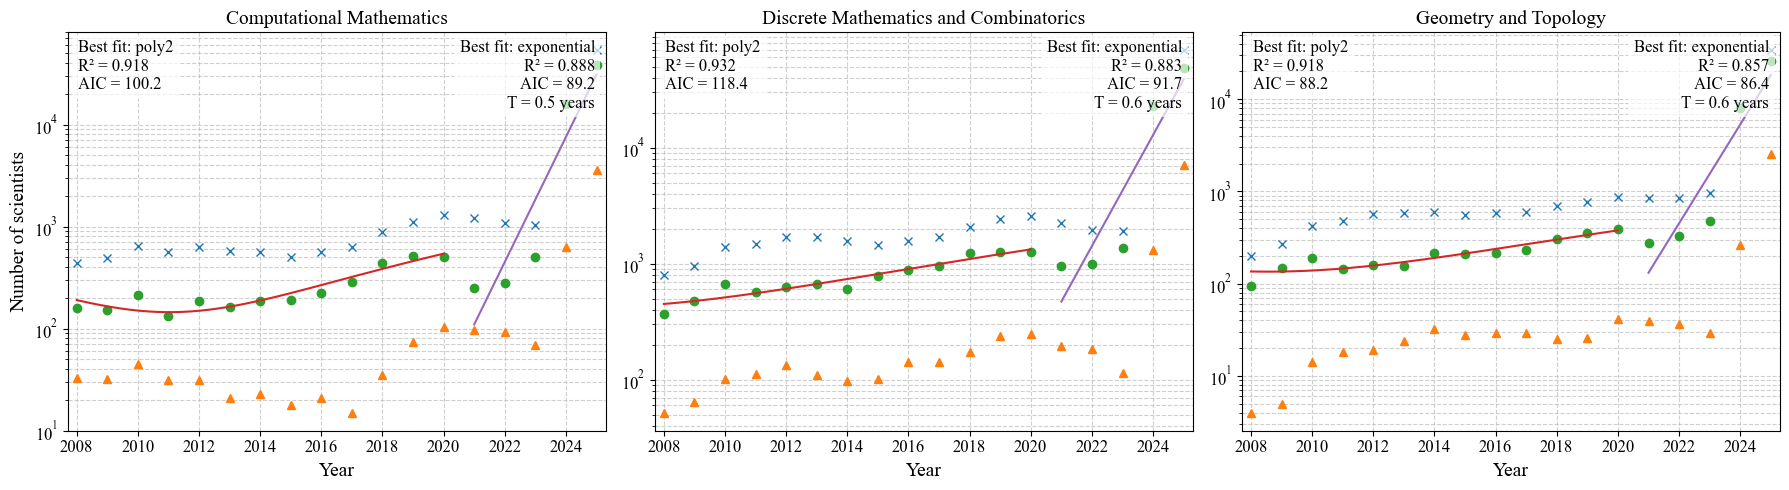

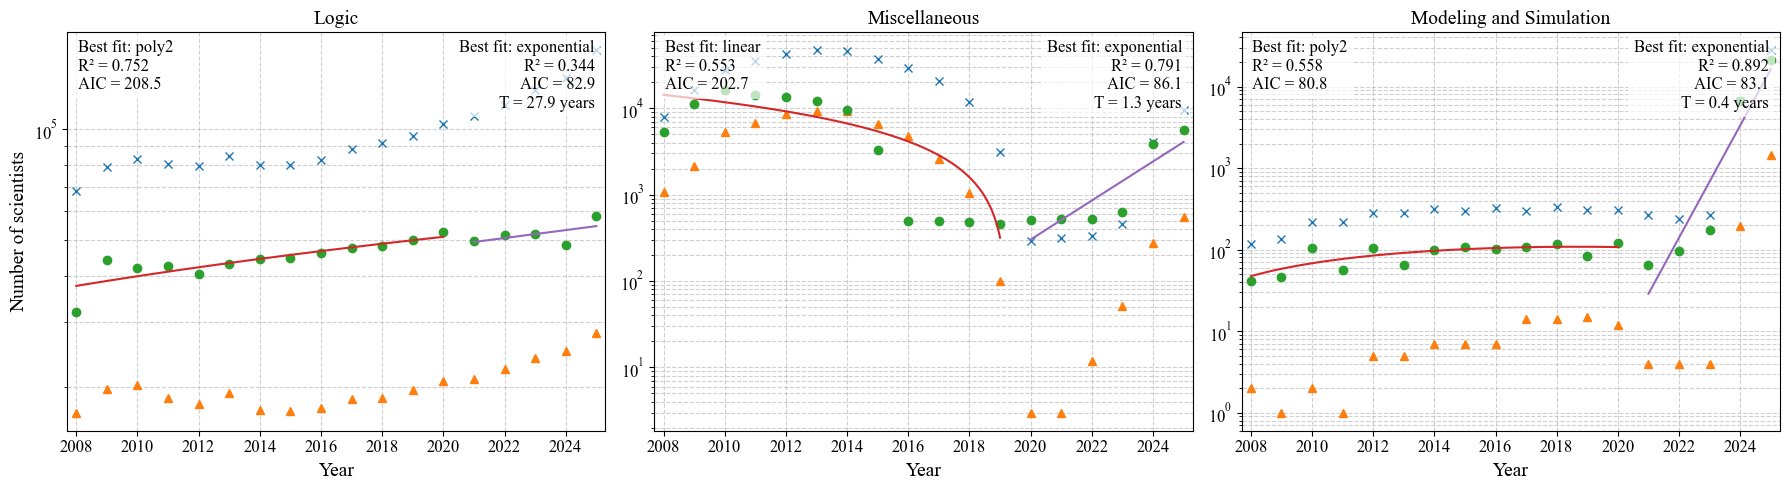

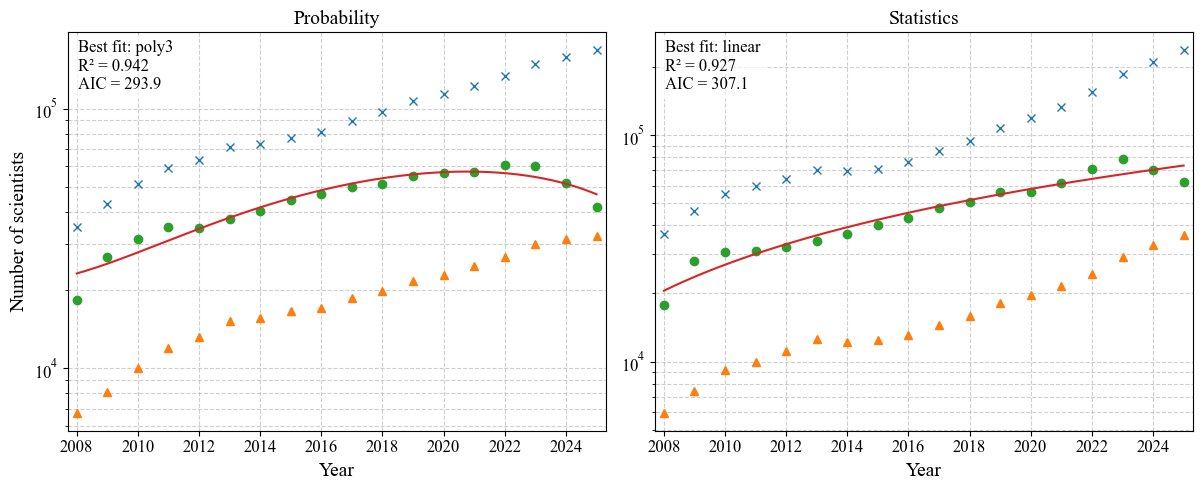

In [28]:
figures = plots.plot_community_fields_in_pages(
    fields=fields,
    community_by_field=community_by_field,
    growth_fits_by_field=community_growth_fits_by_field,
    outdir=outdir,
    outname_prefix="authorsGrowthFieldsNOTrun",
    fontsize=14,
    ncols=3,
    figsize=(18, 5),
    add_legend=False,
)

**4. Bradford's Law by subarea**

In [29]:
journal_counts_by_field = {}

for field in fields:
    journal_counts_by_field[field] = (metrics.clean_journal_counts(dfs_by_field[field]))

top_frac = 0.10
bradford_stats_by_field = {}

for field in fields:

    stats = metrics.bradford_stats(
        journal_counts=journal_counts_by_field[field],
        top_frac=top_frac,
    )

    x_dense = np.linspace(1, len(stats["ranks"]), 800)
    stats["x_dense"] = x_dense
    stats["y_dense"] = metrics.leimkuhler(x = x_dense, a = stats["a"], b = stats["b"])
    bradford_stats_by_field[field] = stats

c:\Users\johanna.cantuna01\Desktop\projects\Bibliometria\src\metrics.py:105: RuntimeWarning: invalid value encountered in log
  return a * np.log(1 + b*x)


In [30]:
for field in fields:
    stats = bradford_stats_by_field[field]
    a = round(stats["a"], 2)
    b = round(stats["b"], 6)

    print("\n" + "=" * 50)
    print(field.replace("_", " "))
    print(f"a = {a} | b = {b}")
    print(f"Equation: C(r) = {a} · ln(1 + {b} · r)")
    print(f"Top {int(top_frac * 100)}%: {stats['percent_top']:.1f}% (top_n={stats['top_n']} / {stats['n_journals']} journals)")


Algebra and Number Theory
a = 2902.48 | b = 0.35928
Equation: C(r) = 2902.48 · ln(1 + 0.35928 · r)
Top 10%: 57.6% (top_n=54 / 549 journals)

Analysis
a = 13131.55 | b = 2.376356
Equation: C(r) = 13131.55 · ln(1 + 2.376356 · r)
Top 10%: 69.7% (top_n=76 / 767 journals)

Applied Mathematics
a = 38205.39 | b = 1.103438
Equation: C(r) = 38205.39 · ln(1 + 1.103438 · r)
Top 10%: 66.5% (top_n=70 / 705 journals)

Computational Mathematics
a = 1799.4 | b = 0.606648
Equation: C(r) = 1799.4 · ln(1 + 0.606648 · r)
Top 10%: 60.7% (top_n=55 / 558 journals)

Discrete Mathematics and Combinatorics
a = 2753.0 | b = 0.817868
Equation: C(r) = 2753.0 · ln(1 + 0.817868 · r)
Top 10%: 62.7% (top_n=58 / 589 journals)

Geometry and Topology
a = 1651.02 | b = 0.35829
Equation: C(r) = 1651.02 · ln(1 + 0.35829 · r)
Top 10%: 56.8% (top_n=53 / 531 journals)

Logic
a = 16051.62 | b = 6.145831
Equation: C(r) = 16051.62 · ln(1 + 6.145831 · r)
Top 10%: 73.4% (top_n=74 / 747 journals)

Miscellaneous
a = 1241.42 | b = 44

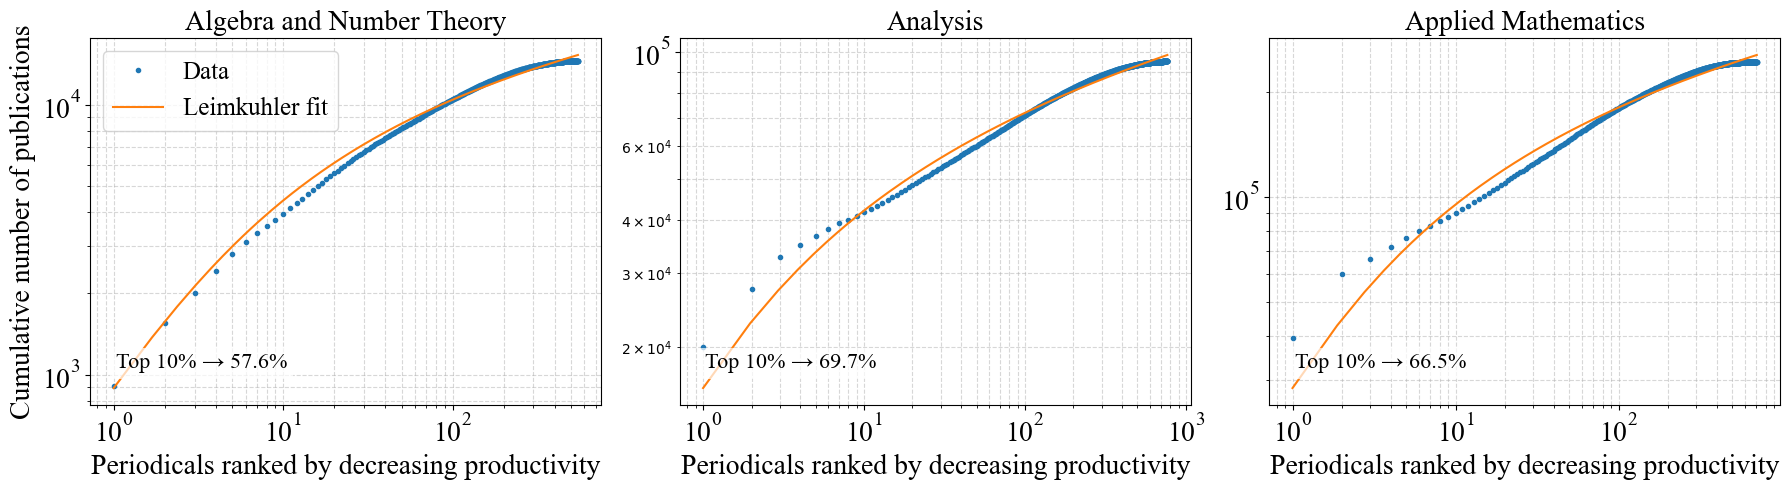

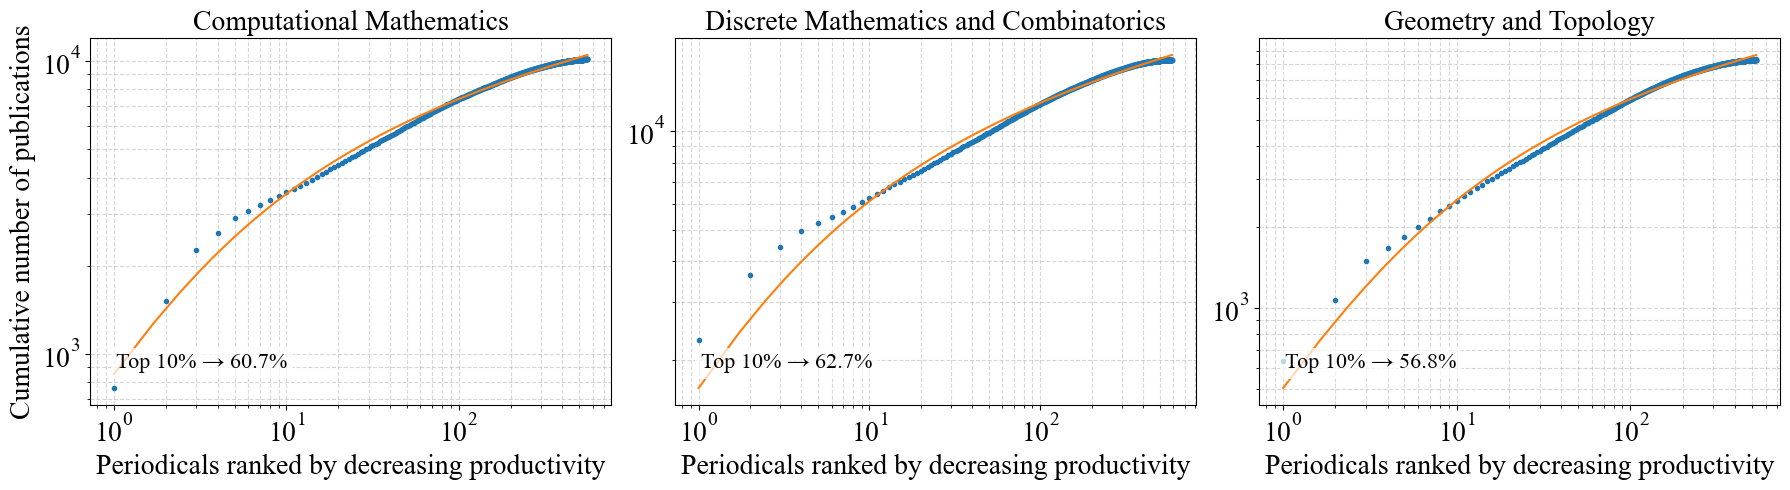

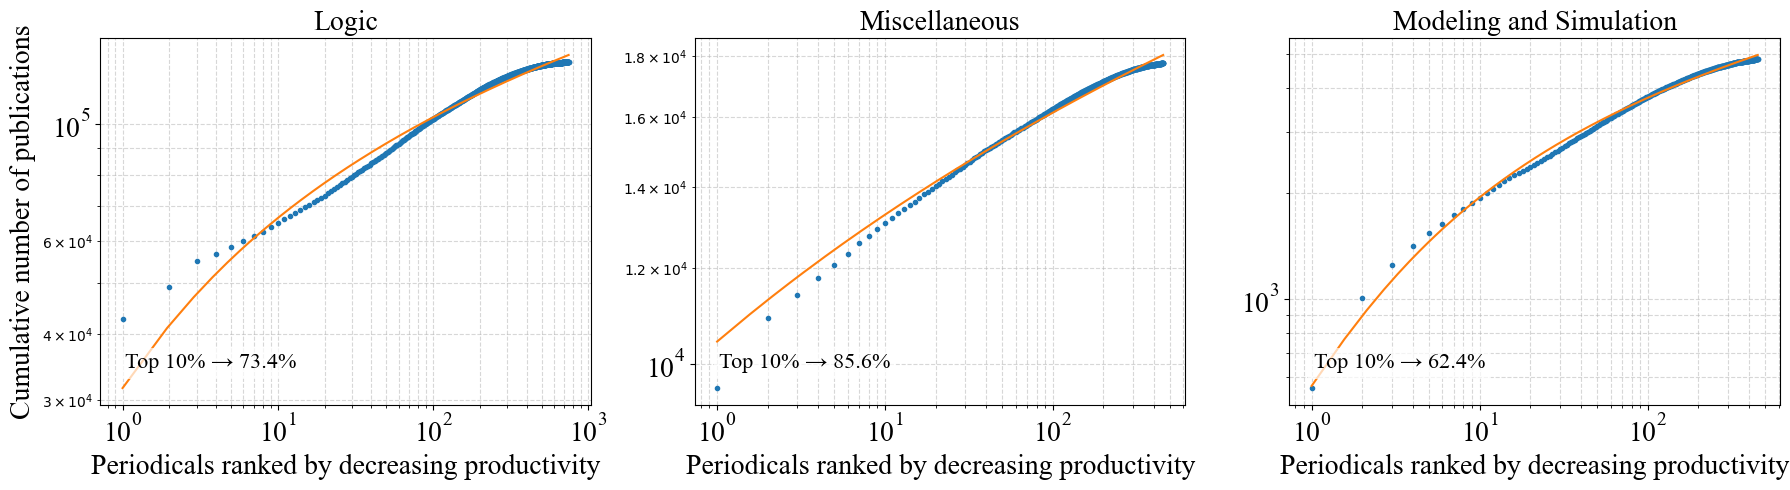

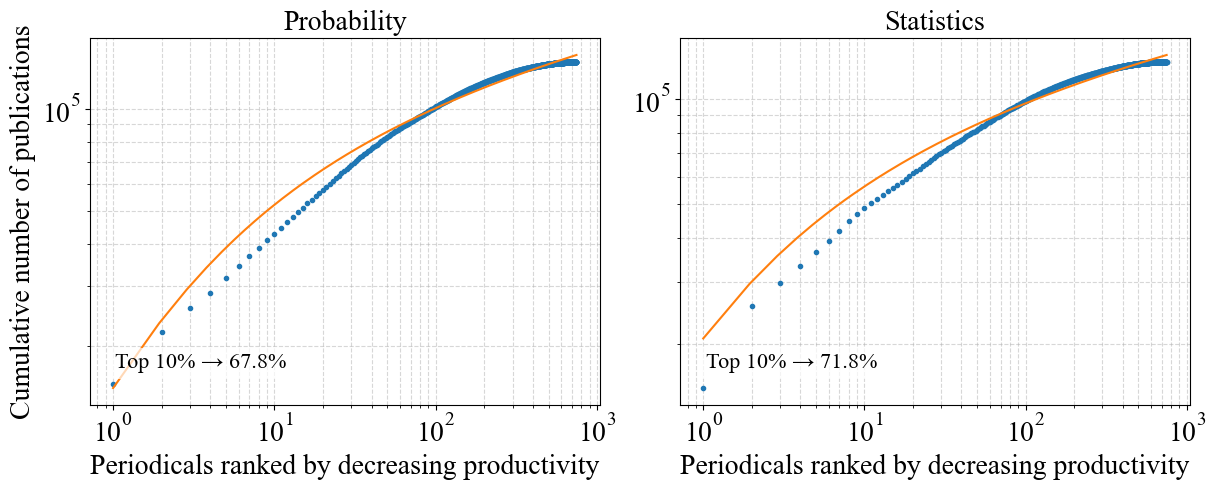

In [31]:
plots.plot_bradford_fields_in_pages(
    fields=fields,
    bradford_stats_by_field=bradford_stats_by_field,
    outdir_pdf=outdir,
    top_frac=top_frac,
    fontsize=20,
    ncols=3,
    fixed_ylim=None,
    outname_prefix="BradfordFields",
)

**5. A comparative between selected areas**

In [32]:
with open("country_patterns.json", "r", encoding="utf-8") as f:
    COUNTRY_PATTERNS = json.load(f)

In [33]:
dfs_by_field_article = {
    field: df_field[df_field["Document Type"] == "Article"].copy() for field, df_field in dfs_by_field.items()
}

dfs_by_field_cp = {
    field: df_field[df_field["Document Type"] == "Conference paper"].copy() for field, df_field in dfs_by_field.items()
}

In [34]:
for field in fields:
    print(f"\n================ {field} ================")
    
    tagged_article = countries.tag_countries_from_affiliations(
        df=dfs_by_field_article[field],
        col_affil="Affiliations",
        country_patterns=COUNTRY_PATTERNS,
        out_col_list="countries_list",
        out_col_str="countries_str"
    )
    country_counts_article = (tagged_article.explode("countries_list").dropna(subset=["countries_list"])["countries_list"].value_counts())
    
    tagged_cp = countries.tag_countries_from_affiliations(
        df=dfs_by_field_cp[field],
        col_affil="Affiliations",
        country_patterns=COUNTRY_PATTERNS,
        out_col_list="countries_list",
        out_col_str="countries_str"
    )
    country_counts_cp = (tagged_cp.explode("countries_list").dropna(subset=["countries_list"])["countries_list"].value_counts())
    
    total_articles = len(tagged_article)

    print("=========== Articles ===========")
    top10_sa_articles = (
        country_counts_article
        .head(10)
        .to_frame("publications")
        .assign(percent=lambda x: x["publications"] / total_articles * 100).round(2)
    )
    print(top10_sa_articles)

    total_cp = len(tagged_cp)
    print("=========== Conference paper ===========")
    top10_sa_cp = (
        country_counts_cp
        .head(10)
        .to_frame("publications")
        .assign(percent=lambda x: x["publications"] / total_cp * 100).round(2)
    )
    print(top10_sa_cp)


================ Algebra_and_Number_Theory ================
=========== Articles ===========
                publications  percent
countries_list                       
China                   4338    38.52
United States           1530    13.59
India                   1104     9.80
United Kingdom           593     5.27
France                   591     5.25
Germany                  556     4.94
Italy                    517     4.59
Saudi Arabia             419     3.72
Iran                     367     3.26
Spain                    366     3.25
=========== Conference paper ===========
                publications  percent
countries_list                       
China                   2041    36.19
United States           1148    20.35
India                    344     6.10
France                   306     5.43
Germany                  285     5.05
United Kingdom           250     4.43
Japan                    220     3.90
Canada                   147     2.61
Italy                    147 